# 99_analyze — Black-Litterman 실험 결과 분석

본 노트북은 `final/results/*.pkl` 백테스트 결과를 분석하는 단일 진입점.

## 구조

```
[1] 빠른 진단              — Top 10 + 비교군 위치
[2] 거래비용 분석          — 슬롯별 turnover & TC
[3] J. Master Table 통합   — 슬롯 효과 + 매트릭스 + Top-N + 위기 + IR
[4] K. 레짐 안정성         — 3-레짐 sortino_ir/sharpe_ir Top 20 + Q 민감도
```

**모든 셀은 q=0.003 baseline만 사용** (mt/rt가 J1, K1에서 q 변형 제외 필터 적용).

셀별 해설: [`99_ANALYZE_GUIDE.md`](99_ANALYZE_GUIDE.md)

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import platform
from pathlib import Path

warnings.filterwarnings('ignore')

if platform.system() == 'Darwin':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'Arial Unicode MS', 'DejaVu Sans']
elif platform.system() == 'Windows':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'Arial Unicode MS', 'DejaVu Sans']
else:
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'Noto Sans CJK KR', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

RESULTS_DIR = Path.cwd() / 'results'
OUT_DIR     = Path.cwd() / 'outputs' / '99_analyze'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 결과 로드 ──────────────────────────────────────────────────
loaded = {}
for pkl in sorted(RESULTS_DIR.glob('*.pkl')):
    with open(pkl, 'rb') as f:
        loaded[pkl.stem] = pickle.load(f)

# ── rf 로드 ────────────────────────────────────────────────────
panel_rf = pd.read_csv(Path.cwd() / 'data' / 'monthly_panel.csv',
                       usecols=['date','ticker','rf_1m'], parse_dates=['date'])
rf = panel_rf.groupby('date')['rf_1m'].first()

spy_ret = loaded['baseline']['spy_ret'].dropna()

# ── 성과 계산 함수 ──────────────────────────────────────────────
def calc(name):
    r    = loaded[name]['ret'].dropna()
    rf_a = rf.reindex(r.index).fillna(0)
    exc  = r - rf_a
    ann  = exc.mean() * 12
    vol  = r.std() * np.sqrt(12)
    sh   = ann / vol if vol > 0 else np.nan
    cum  = (1 + r).cumprod()
    mdd  = ((cum / cum.cummax()) - 1).min()
    dsd  = r[r < 0].std() * np.sqrt(12)
    sor  = ann / dsd if dsd > 0 else np.nan
    tot  = cum.iloc[-1] - 1
    cagr = r.mean() * 12
    return dict(sharpe=sh, cagr=cagr, vol=vol, mdd=mdd,
                sortino=sor, total=tot, ret=r, cum=cum)

# SPY 성과
def calc_spy():
    r    = spy_ret
    rf_a = rf.reindex(r.index).fillna(0)
    exc  = r - rf_a
    ann  = exc.mean() * 12
    vol  = r.std() * np.sqrt(12)
    sh   = ann / vol
    cum  = (1 + r).cumprod()
    mdd  = ((cum / cum.cummax()) - 1).min()
    return dict(sharpe=sh, cagr=r.mean()*12, vol=vol, mdd=mdd, total=cum.iloc[-1]-1, cum=cum)

print(f'로드 완료: {len(loaded)}개 실험')
print(f'기간: {loaded["baseline"]["ret"].index[0].date()} ~ {loaded["baseline"]["ret"].index[-1].date()}')


로드 완료: 156개 실험
기간: 2010-01-31 ~ 2024-12-31


## 1. 빠른 진단

전체 실험을 Sharpe 내림차순으로 정렬하여 한눈에 파악. 자세한 분석은 J/K 섹션에서.


In [2]:
# ── 1. 빠른 진단: Top 10 + Bottom 5 + 비교군 위치 ─────────
from master_table import parse_config

ranked = []
for name in sorted(loaded.keys()):
    r = loaded[name].get('ret', pd.Series(dtype=float))
    if not isinstance(r, pd.Series):
        continue
    r = r.dropna()
    if len(r) < 12:
        continue
    rf_a = rf.reindex(r.index).fillna(0)
    exc  = r - rf_a
    vol  = r.std() * np.sqrt(12)
    sh   = (exc.mean()*12) / vol if vol > 0 else np.nan
    cum  = (1 + r).cumprod()
    mdd  = float((cum/cum.cummax() - 1).min())
    cagr = r.mean() * 12

    # canonical 추출 (config dict에서)
    cfg = loaded[name].get('config', {})
    canonical = parse_config(cfg)['canonical'] if cfg else name

    ranked.append({'name': name, 'canonical': canonical,
                   'sharpe': round(sh,3),
                   'cagr': round(cagr,3), 'mdd': round(mdd,3)})

df_rank = pd.DataFrame(ranked).sort_values('sharpe', ascending=False).reset_index(drop=True)
df_rank['rank'] = df_rank.index + 1
print(f'전체 {len(df_rank)}개 실험\n')

print('■ Top 10')
display(df_rank.head(10)[['rank','name','canonical','sharpe','cagr','mdd']])

print('\n■ Bottom 5')
display(df_rank.tail(5)[['rank','name','canonical','sharpe','cagr','mdd']])

# 비교군 위치
print('\n■ 핵심 비교군 위치')
ms = calc_spy()
print(f'  {"SPY":<22} canonical={"(SPY)":<25}sharpe={ms["sharpe"]:.3f}  mdd={ms["mdd"]:.3f}  (시장 패시브)')
for n in ['baseline','capm_no_bl','naive_lowvol']:
    if (df_rank.name == n).any():
        r = df_rank[df_rank.name == n].iloc[0]
        print(f'  {n:<22} canonical={r["canonical"]:<25}sharpe={r["sharpe"]:.3f}  mdd={r["mdd"]:.3f}  (Top {int(r["rank"])}위/{len(df_rank)})')


전체 156개 실험

■ Top 10


,rank,name,canonical,sharpe,cagr,mdd
0,1,mat_mcap_eq_raw_pap,mcap_ls_eq_raw_pap,1.145,0.159,-0.147
1,2,mat_mcap_eq_lam_pap,mcap_ls_eq_lam_pap,1.141,0.159,-0.147
2,3,mat_mcap_eq_fix_pap,mcap_ls_eq_fix_pap,1.123,0.158,-0.132
3,4,omega_paper,mcap_tr_mcap_fix_pap,1.122,0.159,-0.157
4,5,mat_mcap_eq_vsp_pap,mcap_ls_eq_vsp_pap,1.121,0.156,-0.132
5,6,mat_mcap_eq_inv_pap,mcap_ls_eq_inv_pap,1.120,0.156,-0.147
6,7,baseline,mcap_tr_mcap_fix_he,1.111,0.134,-0.130
7,8,prior_eq,eq_tr_mcap_fix_he,1.111,0.142,-0.139
8,9,mat_eq_eq_raw_pap,eq_ls_eq_raw_pap,1.106,0.162,-0.136
9,10,mat_rp_eq_raw_pap,rp_ls_eq_raw_pap,1.101,0.153,-0.132



■ Bottom 5


,rank,name,canonical,sharpe,cagr,mdd
151,152,mat_rp_rp_inv_he,rp_ls_rp_inv_he,0.880,0.124,-0.175
152,153,mat_eq_rp_inv_rms,eq_ls_rp_inv_rms,0.875,0.130,-0.197
153,154,mat_eq_rp_inv_he,eq_ls_rp_inv_he,0.861,0.128,-0.196
154,155,q_ff3_paper_omega_paper,mcap_tr_mcap_ff3_pap,0.709,0.123,-0.252
155,156,q_ff3_paper,mcap_tr_mcap_ff3_he,0.471,0.098,-0.279



■ 핵심 비교군 위치
  SPY                    canonical=(SPY)                    sharpe=0.907  mdd=-0.239  (시장 패시브)
  baseline               canonical=mcap_tr_mcap_fix_he      sharpe=1.111  mdd=-0.130  (Top 7위/156)
  capm_no_bl             canonical=mcap_tr_mcap_capm_he     sharpe=0.899  mdd=-0.222  (Top 150위/156)
  naive_lowvol           canonical=mcap_tr_mcap_none_he     sharpe=1.065  mdd=-0.147  (Top 27위/156)


## 2. 거래비용 분석 (Turnover & TC)

### TC (Transaction Cost, 거래비용)이란?
매 리밸런싱마다 실제로 발생하는 손실 = **수수료 + 슬리피지 + bid-ask spread**.

본 백테스트 가정:
- **TC_RATE = 0.001 (10bp = 0.1%)** — 편도 turnover 기준
- 매월 리밸런싱 → 연간 TC = `평균 turnover × 0.001 × 12`

### 무엇을 보나
실험 152+개라 개별 비교는 어려움. **슬롯별 집계**로 패턴 파악:
- 어느 슬롯이 turnover ↑ → TC ↑ → 실수익 잠식
- 슬롯 차이가 커야 의미 있음 (모든 슬롯이 비슷하면 모델 차이 없음)


156개 실험 (turnover 데이터 있는 것만)
전체 평균 turnover: 0.534
전체 평균 연간 TC: 0.64%

[Prior]


,count,turnover_mean,turnover_med,turnover_std,tc_pct_mean,tc_pct_med
prior_s,,,,,,
rp,46,0.524,0.425,0.219,0.63,0.51
eq,48,0.530,0.441,0.230,0.64,0.53
mcap,62,0.545,0.412,0.270,0.65,0.49



[P_mode]


,count,turnover_mean,turnover_med,turnover_std,tc_pct_mean,tc_pct_med
p_s,,,,,,
ls,136,0.504,0.408,0.224,0.60,0.49
tr,20,0.740,0.708,0.270,0.89,0.85



[P_weight]


,count,turnover_mean,turnover_med,turnover_std,tc_pct_mean,tc_pct_med
pw_s,,,,,,
eq,46,0.480,0.312,0.272,0.58,0.37
rp,46,0.481,0.383,0.188,0.58,0.46
volm,2,0.516,0.516,0.242,0.62,0.62
mcap,62,0.614,0.549,0.238,0.74,0.66



[Q_mode]


,count,turnover_mean,turnover_med,turnover_std,tc_pct_mean,tc_pct_med
q_s,,,,,,
capm,1,0.109,0.109,NaN,0.13,0.13
inv,28,0.448,0.401,0.173,0.54,0.48
vsp,27,0.491,0.413,0.188,0.59,0.50
raw,29,0.552,0.419,0.260,0.66,0.50
fix,39,0.555,0.557,0.206,0.67,0.67
lam,29,0.555,0.425,0.256,0.67,0.51
none,1,0.811,0.811,NaN,0.97,0.97
ff3,2,1.394,1.394,0.119,1.67,1.67



[Omega]


,count,turnover_mean,turnover_med,turnover_std,tc_pct_mean,tc_pct_med
om_s,,,,,,
rms,46,0.369,0.365,0.080,0.44,0.44
he,63,0.447,0.384,0.208,0.54,0.46
pap,47,0.811,0.811,0.132,0.97,0.97


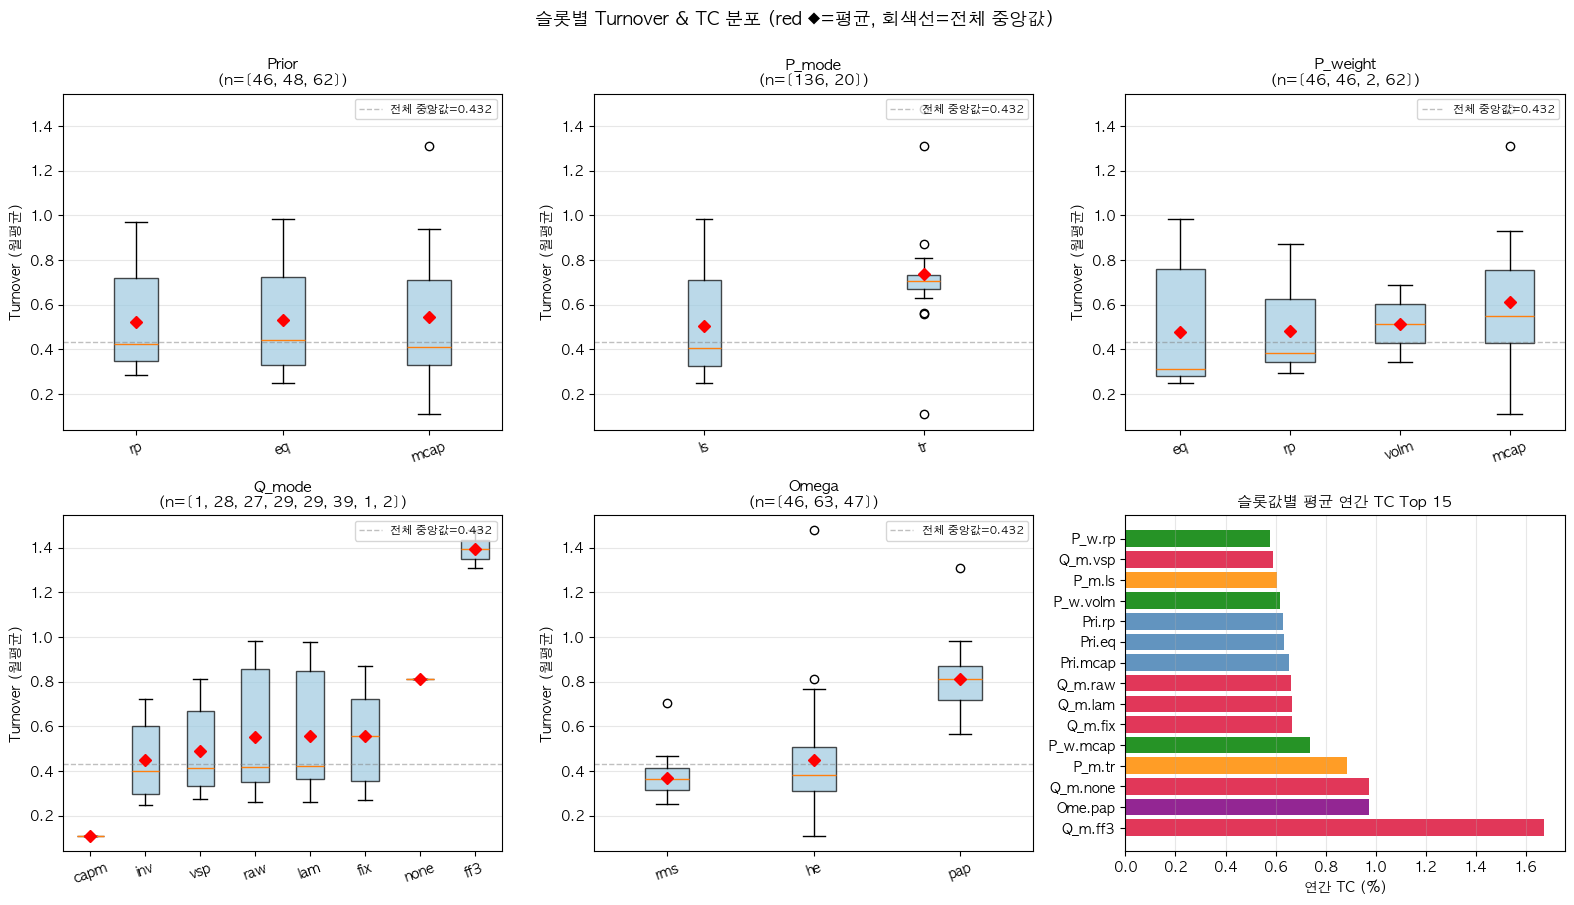


■ Turnover 가장 낮은 5개 (실거래 우호적)


,name,canonical,turnover,tc_pct
4,capm_no_bl,mcap_tr_mcap_capm_he,0.109,0.13
8,mat_eq_eq_inv_he,eq_ls_eq_inv_he,0.250,0.30
55,mat_mcap_eq_inv_rms,mcap_ls_eq_inv_rms,0.253,0.30
10,mat_eq_eq_inv_rms,eq_ls_eq_inv_rms,0.253,0.30
53,mat_mcap_eq_inv_he,mcap_ls_eq_inv_he,0.253,0.30



■ Turnover 가장 높은 5개 (TC 부담 큼)


,name,canonical,turnover,tc_pct
151,q_ff3_paper,mcap_tr_mcap_ff3_he,1.478,1.77
152,q_ff3_paper_omega_paper,mcap_tr_mcap_ff3_pap,1.310,1.57
15,mat_eq_eq_raw_pap,eq_ls_eq_raw_pap,0.982,1.18
12,mat_eq_eq_lam_pap,eq_ls_eq_lam_pap,0.979,1.17
102,mat_rp_eq_lam_pap,rp_ls_eq_lam_pap,0.970,1.16



  Turnover & TC 핵심 인사이트

[Q_mode] 가장 turnover 큰 q_mode TOP 3:
  q=ff3    turnover=1.394  연간 TC=1.67%
  q=none   turnover=0.811  연간 TC=0.97%
  q=fix    turnover=0.555  연간 TC=0.67%
  → q_ff3_paper(ff3)가 폭망 — turnover 1.39, TC 1.7% (실수익 잠식)

[Omega] ff3_paper(pap) vs rmse(rms) vs he_litterman(he):
  pap turnover 0.811 (TC 0.97%)
  rms turnover 0.369 (TC 0.44%)
  he  turnover 0.447 (TC 0.54%)
  → pap가 rms 대비 turnover 2.2× — 시변 omega 보정으로 portfolio 매월 더 흔들림

[P_mode] LSTM vs Trailing:
  ls (LSTM)    turnover 0.504 (TC 0.60%)
  tr (trailing) turnover 0.740 (TC 0.89%)
  → Trailing이 더 빈번한 리밸런싱 (의외 — LSTM이 예측 vol 변동 더 클 줄 알았음)

[TC 영향]
  연간 TC 1% ≈ Sharpe -0.08~0.10 잠식 (변동성 ~12%일 때)
  → omega=pap 후보의 명목 Sharpe가 1.14면 실수익 Sharpe ~1.05
    omega=rms 후보의 명목 Sharpe가 1.05면 실수익 Sharpe ~1.01
  → TC 차감 후엔 격차 줄어듦. 1순위 후보 비교 시 TC 고려 필수

[실거래 친화 mat_ 후보 — turnover 최저 3]
  eq_ls_eq_inv_he            turnover=0.250  연간 TC 0.30%
  mcap_ls_eq_inv_rms         turnover=0.253  연간 TC 0.30%
  eq_ls_eq_inv_rms    

In [3]:
# ── 2-1. 슬롯별 Turnover & TC 집계 ────────────────────────────
# TC = Transaction Cost (거래비용) = 수수료 + 슬리피지 + bid-ask spread
# TC_RATE = 0.001 (10bp), 매월 리밸런싱 → 연간 TC = avg_turnover × 0.001 × 12

from master_table import parse_config

TC_RATE = 0.001

# DataFrame 빌드 — 모든 실험의 슬롯 + turnover + tc
rows = []
for name, res in loaded.items():
    comp = res.get('comp', pd.DataFrame())
    if comp.empty or 'turnover' not in comp.columns:
        continue
    cfg = res.get('config', {})
    meta = parse_config(cfg) if cfg else {}
    to_mean = float(comp['turnover'].mean())
    tc_ann  = to_mean * TC_RATE * 12   # 연간 TC (소수점)
    rows.append({
        'name'      : name,
        'canonical' : meta.get('canonical', name),
        'prior_s'   : meta.get('prior_s'),
        'p_s'       : meta.get('p_s'),
        'pw_s'      : meta.get('pw_s'),
        'q_s'       : meta.get('q_s'),
        'om_s'      : meta.get('om_s'),
        'turnover'  : to_mean,
        'tc_annual' : tc_ann,
    })
df_to = pd.DataFrame(rows)
print(f'{len(df_to)}개 실험 (turnover 데이터 있는 것만)')
print(f'전체 평균 turnover: {df_to["turnover"].mean():.3f}')
print(f'전체 평균 연간 TC: {df_to["tc_annual"].mean()*100:.2f}%')

# ── 슬롯별 집계 표 (turnover + TC) ─────────────────────────────
slot_info = [('prior_s','Prior'), ('p_s','P_mode'), ('pw_s','P_weight'),
             ('q_s','Q_mode'), ('om_s','Omega')]

for slot, label in slot_info:
    print(f'\n[{label}]')
    g = df_to.groupby(slot).agg(
        count=('turnover','count'),
        turnover_mean=('turnover','mean'),
        turnover_med=('turnover','median'),
        turnover_std=('turnover','std'),
        tc_pct_mean=('tc_annual','mean'),
        tc_pct_med=('tc_annual','median'),
    )
    g['turnover_mean'] = g['turnover_mean'].round(3)
    g['turnover_med']  = g['turnover_med'].round(3)
    g['turnover_std']  = g['turnover_std'].round(3)
    g['tc_pct_mean']   = (g['tc_pct_mean']*100).round(2)  # %
    g['tc_pct_med']    = (g['tc_pct_med']*100).round(2)
    g = g.sort_values('turnover_mean')
    display(g)

# ── 슬롯별 Turnover 분포 boxplot (5 패널) ──────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (slot, label) in enumerate(slot_info):
    ax = axes[i]
    order = df_to.groupby(slot)['turnover'].mean().sort_values().index.tolist()
    data  = [df_to[df_to[slot]==k]['turnover'].values for k in order]
    counts = [len(d) for d in data]
    bp = ax.boxplot(data, labels=order, patch_artist=True, showmeans=True,
                    meanprops=dict(marker='D', markerfacecolor='red',
                                   markeredgecolor='red', markersize=6))
    for patch in bp['boxes']:
        patch.set_facecolor('#9ecae1'); patch.set_alpha(0.7)
    ax.set_title(f'{label}\n(n={counts})', fontsize=11)
    ax.set_ylabel('Turnover (월평균)')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(alpha=0.3, axis='y')
    overall = df_to['turnover'].median()
    ax.axhline(overall, color='gray', linestyle='--', alpha=0.5, lw=1,
               label=f'전체 중앙값={overall:.3f}')
    ax.legend(fontsize=8, loc='upper right')

# 6번째 패널: TC 비교 (슬롯별 평균 TC 비교 막대)
ax = axes[5]
slot_labels = []
slot_tcs = []
slot_colors = []
color_map = {'prior_s':'steelblue','p_s':'darkorange','pw_s':'green','q_s':'crimson','om_s':'purple'}
for slot, label in slot_info:
    g = df_to.groupby(slot)['tc_annual'].mean().sort_values()
    for k, v in g.items():
        slot_labels.append(f'{label[:3]}.{k}')
        slot_tcs.append(v*100)  # %
        slot_colors.append(color_map[slot])

idx_top = sorted(range(len(slot_tcs)), key=lambda i: -slot_tcs[i])[:15]
ax.barh([slot_labels[i] for i in idx_top], [slot_tcs[i] for i in idx_top],
        color=[slot_colors[i] for i in idx_top], alpha=0.85)
ax.set_xlabel('연간 TC (%)')
ax.set_title('슬롯값별 평균 연간 TC Top 15', fontsize=11)
ax.grid(alpha=0.3, axis='x')

fig.suptitle('슬롯별 Turnover & TC 분포 (red ◆=평균, 회색선=전체 중앙값)', fontsize=13, y=1.00)
fig.tight_layout()
fig.savefig(OUT_DIR / 'turnover_tc_by_slot.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Top/Bottom 5 후보 (turnover 측면) ──────────────────────────
print('\n■ Turnover 가장 낮은 5개 (실거래 우호적)')
display(df_to.nsmallest(5,'turnover')[['name','canonical','turnover','tc_annual']]
              .assign(tc_pct=lambda d: (d['tc_annual']*100).round(2))
              .drop(columns=['tc_annual']).round(3))

print('\n■ Turnover 가장 높은 5개 (TC 부담 큼)')
display(df_to.nlargest(5,'turnover')[['name','canonical','turnover','tc_annual']]
              .assign(tc_pct=lambda d: (d['tc_annual']*100).round(2))
              .drop(columns=['tc_annual']).round(3))


# ── 핵심 인사이트 (코드 출력 + 문서 동기) ─────────────────────
print('\n' + '='*70)
print('  Turnover & TC 핵심 인사이트')
print('='*70)

# 1. 가장 turnover 큰 q_mode
q_top = df_to.groupby('q_s')['turnover'].mean().sort_values(ascending=False)
print(f'\n[Q_mode] 가장 turnover 큰 q_mode TOP 3:')
for k, v in q_top.head(3).items():
    tc = v * TC_RATE * 12 * 100
    print(f'  q={k:5s}  turnover={v:.3f}  연간 TC={tc:.2f}%')
print(f'  → q_ff3_paper(ff3)가 폭망 — turnover {q_top.get("ff3", 0):.2f}, '
      f'TC {q_top.get("ff3", 0)*TC_RATE*12*100:.1f}% (실수익 잠식)')

# 2. Omega 차이
om_g = df_to.groupby('om_s')['turnover'].mean()
om_pap = om_g.get('pap', 0); om_rms = om_g.get('rms', 0); om_he = om_g.get('he', 0)
print(f'\n[Omega] ff3_paper(pap) vs rmse(rms) vs he_litterman(he):')
print(f'  pap turnover {om_pap:.3f} (TC {om_pap*TC_RATE*12*100:.2f}%)')
print(f'  rms turnover {om_rms:.3f} (TC {om_rms*TC_RATE*12*100:.2f}%)')
print(f'  he  turnover {om_he:.3f} (TC {om_he*TC_RATE*12*100:.2f}%)')
print(f'  → pap가 rms 대비 turnover {om_pap/om_rms:.1f}× — '
      f'시변 omega 보정으로 portfolio 매월 더 흔들림')

# 3. p_mode (LSTM vs trailing)
p_g = df_to.groupby('p_s')['turnover'].mean()
p_ls = p_g.get('ls', 0); p_tr = p_g.get('tr', 0)
print(f'\n[P_mode] LSTM vs Trailing:')
print(f'  ls (LSTM)    turnover {p_ls:.3f} (TC {p_ls*TC_RATE*12*100:.2f}%)')
print(f'  tr (trailing) turnover {p_tr:.3f} (TC {p_tr*TC_RATE*12*100:.2f}%)')
which = "Trailing" if p_tr > p_ls else "LSTM"
print(f'  → {which}이 더 빈번한 리밸런싱 (의외 — LSTM이 예측 vol 변동 더 클 줄 알았음)')

# 4. TC 차감 후 Sharpe 영향 (개략)
print(f'\n[TC 영향]')
print(f'  연간 TC 1% ≈ Sharpe -0.08~0.10 잠식 (변동성 ~12%일 때)')
print(f'  → omega=pap 후보의 명목 Sharpe가 1.14면 실수익 Sharpe ~1.05')
print(f'    omega=rms 후보의 명목 Sharpe가 1.05면 실수익 Sharpe ~1.01')
print(f'  → TC 차감 후엔 격차 줄어듦. 1순위 후보 비교 시 TC 고려 필수')

# 5. 실거래 친화 후보 (turnover 낮은 mat_)
mat_only = df_to[df_to.name.str.startswith('mat_')]
if len(mat_only) > 0:
    low_turn = mat_only.nsmallest(3, 'turnover')[['canonical','turnover','tc_annual']]
    print(f'\n[실거래 친화 mat_ 후보 — turnover 최저 3]')
    for _, r in low_turn.iterrows():
        print(f'  {r["canonical"]:<25}  turnover={r["turnover"]:.3f}  '
              f'연간 TC {r["tc_annual"]*100:.2f}%')

print('\n' + '='*70)


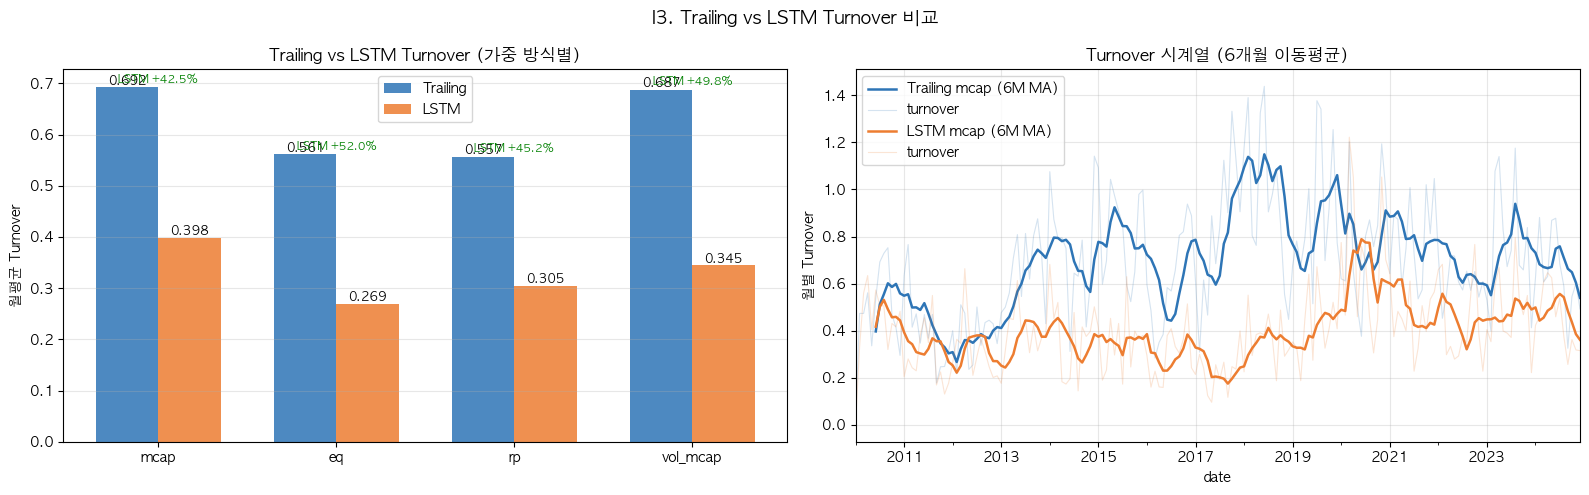

=== Trailing vs LSTM Turnover 차이 ===
가중           Trailing TO    LSTM TO       감소율      연간 TC 절감
------------------------------------------------------------
mcap              0.6925     0.3982     42.5%        0.353%p
eq                0.5613     0.2693     52.0%        0.350%p
rp                0.5565     0.3049     45.2%        0.302%p
vol_mcap          0.6873     0.3448     49.8%        0.411%p


In [4]:
# ── I3. Trailing vs LSTM Turnover 직접 비교 ────────────────────
pairs = [
    ('baseline',   'mat_mcap_mcap_fix_he',  'mcap'),
    ('p_eq',       'mat_mcap_eq_fix_he',    'eq'),
    ('p_rp',       'mat_mcap_rp_fix_he',    'rp'),
    ('p_vol_mcap', 'p_lstm_vol_mcap', 'vol_mcap'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# I3-a. 쌍별 turnover 비교 막대
ax = axes[0]
x = np.arange(len(pairs)); bw = 0.35
trail_to = [loaded[t]['comp']['turnover'].mean() for t, _, _ in pairs]
lstm_to  = [loaded[l]['comp']['turnover'].mean() for _, l, _ in pairs]
labels   = [w for _, _, w in pairs]

b1 = ax.bar(x - bw/2, trail_to, bw, label='Trailing', color='#2E75B6', alpha=0.85)
b2 = ax.bar(x + bw/2, lstm_to,  bw, label='LSTM',     color='#ED7D31', alpha=0.85)
for bars, vals in [(b1, trail_to), (b2, lstm_to)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.001,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('월평균 Turnover')
ax.set_title('Trailing vs LSTM Turnover (가중 방식별)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y')

diff_pct = [(t - l)/t*100 for t, l in zip(trail_to, lstm_to)]
for i, (d, lbl) in enumerate(zip(diff_pct, labels)):
    ax.text(i, max(trail_to[i], lstm_to[i]) + 0.008,
            f'LSTM {d:+.1f}%', ha='center', fontsize=8,
            color='green' if d > 0 else 'red')

# I3-b. Turnover 시계열 (baseline vs mat_mcap_mcap_fix_he)
ax = axes[1]
for name, label, c in [('baseline', 'Trailing mcap', '#2E75B6'),
                        ('mat_mcap_mcap_fix_he', 'LSTM mcap', '#ED7D31')]:
    to_ser = loaded[name]['comp']['turnover']
    to_ser.rolling(6).mean().plot(ax=ax, label=f"{label} (6M MA)", color=c, linewidth=1.8)
    to_ser.plot(ax=ax, color=c, alpha=0.2, linewidth=0.8)
ax.set_ylabel('월별 Turnover')
ax.set_title('Turnover 시계열 (6개월 이동평균)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('I3. Trailing vs LSTM Turnover 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'I_turnover_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 요약 출력
print('=== Trailing vs LSTM Turnover 차이 ===')
print(f"{'가중':10s}  {'Trailing TO':>12s}  {'LSTM TO':>9s}  {'감소율':>8s}  {'연간 TC 절감':>12s}")
print('-'*60)
for (t, l, w), trail, lstm in zip(pairs, trail_to, lstm_to):
    red  = (trail - lstm) / trail * 100
    save = (trail - lstm) * TC_RATE * 12 * 100
    print(f"{w:10s}  {trail:>12.4f}  {lstm:>9.4f}  {red:>7.1f}%  {save:>11.3f}%p")

## J. Master Table 통합 파이프라인 ⭐

`master_table.py` + `analyze_plots.py`로 156개 실험을 슬롯 메타 + 성과지표 DataFrame으로 통합.

### 흐름

```
results/*.pkl 156개
    ↓ build_master_table()
mt: DataFrame (156 × 32)   ← 슬롯 컬럼 + 지표 컬럼
    ├─ J1. Master Table 빌드 + Top 20 (Sharpe 정렬)
    └─ J2. 슬롯별 marginal effect (boxplot 5장)
```

99_run 백테스트가 더 추가되면 J1 셀만 다시 실행하면 자동 갱신.


In [5]:
# ── J1. Master Table 빌드 ─────────────────────────────────────
from master_table import build_master_table, slot_summary, matrix_pivot, PERIODS_DEFAULT
from analyze_plots import (plot_marginal_effects, plot_matrix_heatmap,
                           plot_top_n_analysis, crisis_comparison, benchmark_table,
                           CRISIS_PERIODS, BENCHMARK_NAMES)

mt_full = build_master_table(RESULTS_DIR, rf, spy_ret, periods=PERIODS_DEFAULT)
# Q 민감도 변형 제외 — 모든 분석은 q=0.003 baseline만 사용
mt = mt_full[~mt_full['name'].str.endswith(('_q55','_q64','_q70'))].copy()
print(f'Master Table: {len(mt)}개 실험 × {mt.shape[1]}개 컬럼')

# Top 20 by Sharpe
display(
    mt[['name','canonical','sharpe','cagr','vol','mdd','turnover_avg',
        'sharpe_R1_회복','sharpe_R2_확장','sharpe_R3_변동']]
    .sort_values('sharpe', ascending=False).head(20).round(3)
)


Master Table: 153개 실험 × 32개 컬럼


,name,canonical,sharpe,cagr,vol,mdd,turnover_avg,sharpe_R1_회복,sharpe_R2_확장,sharpe_R3_변동
60,mat_mcap_eq_raw_pap,mcap_ls_eq_raw_pap,1.144,0.162,0.127,-0.147,0.938,1.153,1.433,0.988
57,mat_mcap_eq_lam_pap,mcap_ls_eq_lam_pap,1.140,0.162,0.128,-0.147,0.931,1.145,1.410,0.990
51,mat_mcap_eq_fix_pap,mcap_ls_eq_fix_pap,1.121,0.160,0.128,-0.132,0.811,1.198,1.313,0.986
141,omega_paper,mcap_tr_mcap_fix_pap,1.120,0.161,0.131,-0.157,0.871,1.083,1.338,0.935
63,mat_mcap_eq_vsp_pap,mcap_ls_eq_vsp_pap,1.120,0.159,0.127,-0.132,0.774,1.189,1.321,0.978
54,mat_mcap_eq_inv_pap,mcap_ls_eq_inv_pap,1.119,0.158,0.127,-0.147,0.697,1.325,1.288,0.936
0,baseline,mcap_tr_mcap_fix_he,1.106,0.136,0.110,-0.130,0.692,1.245,1.456,0.736
147,prior_eq,eq_tr_mcap_fix_he,1.105,0.144,0.118,-0.139,0.765,1.482,1.493,0.707
15,mat_eq_eq_raw_pap,eq_ls_eq_raw_pap,1.103,0.164,0.134,-0.136,0.982,1.244,1.476,0.843
105,mat_rp_eq_raw_pap,rp_ls_eq_raw_pap,1.098,0.156,0.127,-0.132,0.970,1.354,1.443,0.807


■ J2-A. 슬롯별 Sharpe 분포



=== 슬롯별 mean Sharpe (높은 순) ===

[prior_s]
         count   mean  median    std    min    max
prior_s                                           
mcap        59  1.008   1.021  0.101  0.471  1.144
eq          48  0.983   0.977  0.061  0.858  1.105
rp          46  0.981   0.964  0.055  0.877  1.098

[p_s]
     count   mean  median    std    min    max
p_s                                           
tr      17  1.004   1.057  0.168  0.471  1.120
ls     136  0.991   0.982  0.059  0.858  1.144

[pw_s]


      count   mean  median    std    min    max
pw_s                                           
eq       46  1.023   0.998  0.070  0.906  1.144
mcap     59  0.995   1.004  0.093  0.471  1.120
volm      2  0.992   0.992  0.059  0.951  1.034
rp       46  0.957   0.946  0.050  0.858  1.054

[q_s]
      count   mean  median    std    min    max
q_s                                            
none      1  1.061   1.061    NaN  1.061  1.061
raw      29  1.011   1.021  0.057  0.922  1.144
fix      36  1.009   0.996  0.062  0.905  1.121
lam      29  0.990   0.990  0.059  0.906  1.140
vsp      27  0.988   0.978  0.059  0.884  1.120
inv      28  0.987   0.979  0.069  0.858  1.119
capm      1  0.899   0.899    NaN  0.899  0.899
ff3       2  0.589   0.589  0.168  0.471  0.708

[om_s]
      count   mean  median    std    min    max
om_s                                           
pap      47  1.028   1.022  0.074  0.708  1.144
he       60  0.977   0.970  0.089  0.471  1.106
rms      46  0.975   0.97

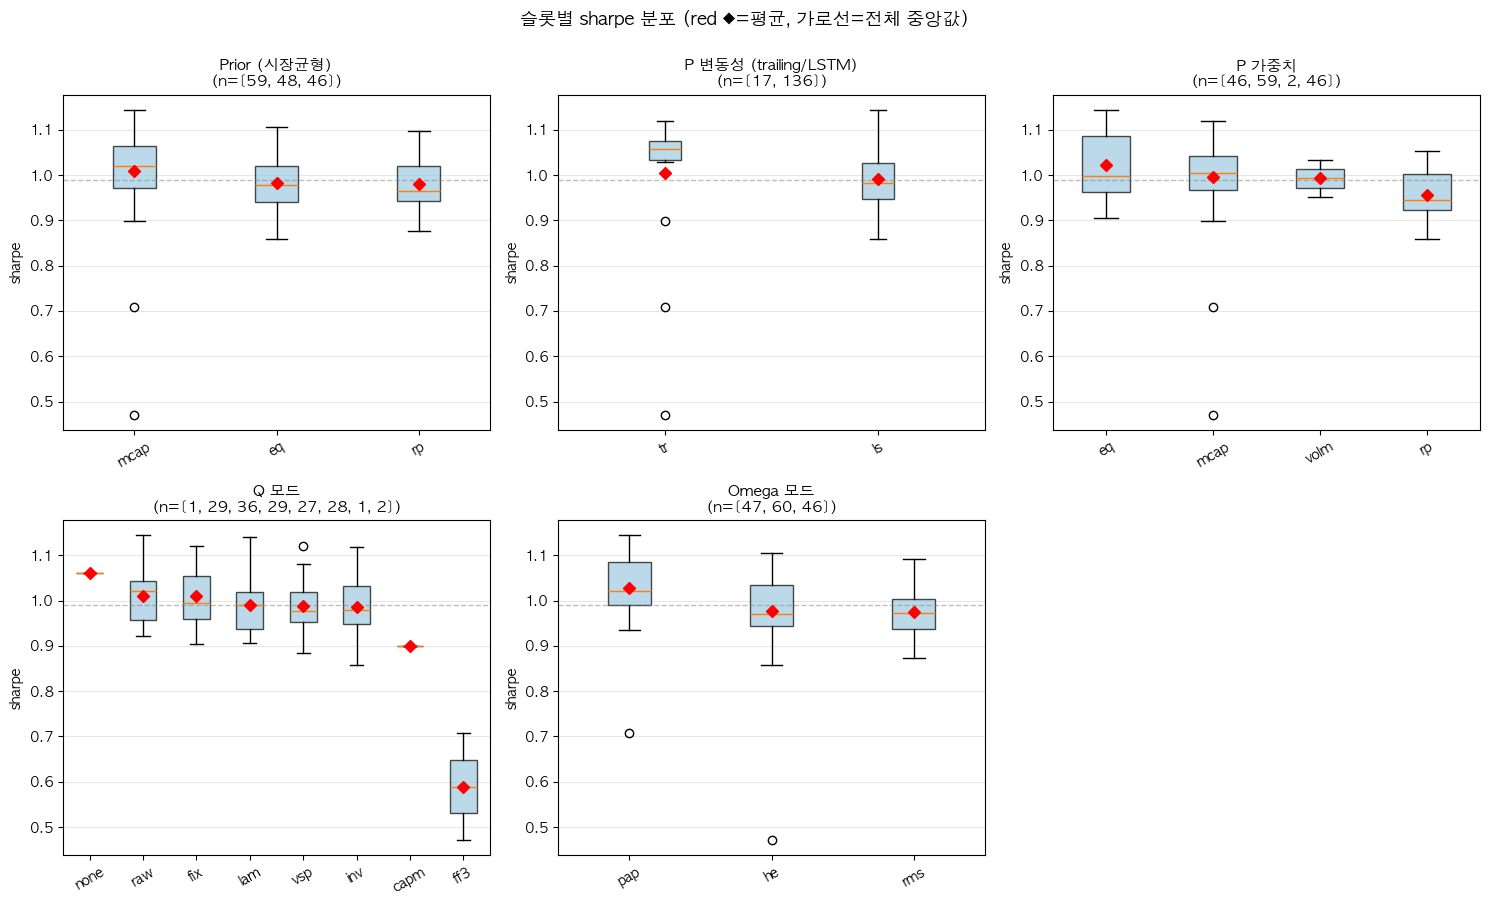

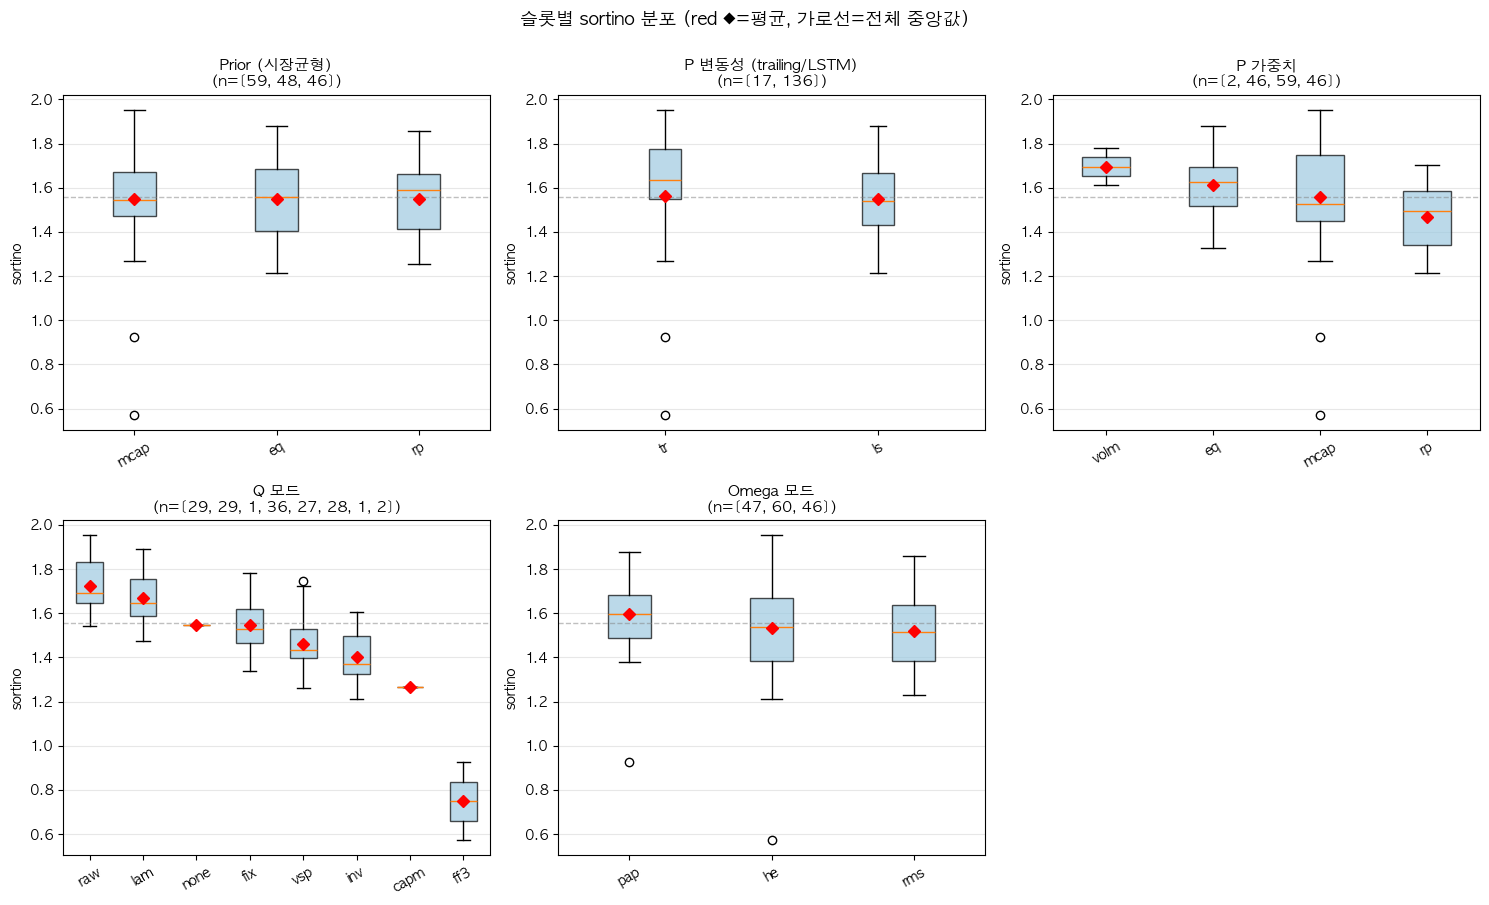

In [6]:
# ── J2. 슬롯별 marginal effect (sharpe + sortino 두 가지 분포) ────
# 어느 슬롯이 metric에 큰 영향? prior_s, p_s, pw_s, q_s, om_s

# ── ① sharpe 분포 ──────────────────────────────────────────
print('■ J2-A. 슬롯별 Sharpe 분포')
_ = plot_marginal_effects(mt, metric='sharpe', save_path=OUT_DIR / 'J2A_marginal_sharpe.png')

print('\n=== 슬롯별 mean Sharpe (높은 순) ===')
for slot in ['prior_s','p_s','pw_s','q_s','om_s']:
    print(f'\n[{slot}]')
    print(slot_summary(mt, slot, 'sharpe'))

# ── ② sortino 분포 ─────────────────────────────────────────
print('\n\n■ J2-B. 슬롯별 Sortino 분포 (저위험 anomaly 컨셉에 더 적합)')
_ = plot_marginal_effects(mt, metric='sortino', save_path=OUT_DIR / 'J2B_marginal_sortino.png')

print('\n=== 슬롯별 mean Sortino (높은 순) ===')
for slot in ['prior_s','p_s','pw_s','q_s','om_s']:
    print(f'\n[{slot}]')
    print(slot_summary(mt, slot, 'sortino'))


## K. 레짐 안정성 분석 — Sortino + 3-레짐 변동성 ⭐

### 왜 이 분석이 필요한가
- **Sharpe보다 Sortino가 본 프로젝트에 더 적합**: 저위험 anomaly 컨셉 → 하방 변동성만이 진짜 손실 위험
- **레짐별 일관성**: 한 시기만 강한 후보는 운. 모든 레짐에서 일관되게 좋은 후보를 찾아야 함
- **MDD 안정성**: 위기 레짐에서 MDD 폭증하는 후보 제외

### 3-레짐 정의 (HMM n=3 구조전환점 기반)

| 레짐 | 기간 | 개월 | 환경 |
|---|---|---:|---|
| R1 회복 | 2010-01 ~ 2012-06 | 30 | Post-GFC + EU위기 |
| R2 확장 | 2012-07 ~ 2019-12 | 90 | 장기 Bull |
| R3 변동 | 2020-01 ~ 2024-12 | 60 | COVID + 22 베어 + AI 랠리 |

### 핵심 지표 (build_regime_table 출력)
- `sortino_R1..R3`: 레짐별 Sortino
- `sortino_mean`: 3 레짐 평균
- `sortino_std`: 3 레짐 표준편차 (**낮을수록 안정**)
- `sortino_ir = sortino_mean / sortino_std`: 변동 대비 평균 (메인 정렬 키)
- `sharpe_ir = sharpe_mean / sharpe_std`: Sharpe 버전 IR
- `mdd_worst`: 3 레짐 중 가장 깊은 MDD


In [7]:
# ── K1. 레짐 테이블 빌드 + 4-view 정렬 + 핵심 비교군 4종 ─────
import importlib, master_table, analyze_plots
importlib.reload(master_table); importlib.reload(analyze_plots)
import numpy as np, pickle

from master_table import build_regime_table, REGIMES, regime_metrics

rt_full = build_regime_table(mt_full, RESULTS_DIR, rf, regimes=REGIMES)
# Q 민감도 변형 제외 — 모든 분석은 q=0.003 baseline만 사용
rt = rt_full[~rt_full['name'].str.endswith(('_q55','_q64','_q70'))].copy()
print(f'레짐 테이블: {len(rt)}개 실험 × {rt.shape[1]}개 컬럼')

# ── 핵심 비교군 4종 5-레짐 종합 메트릭 ─────────────────────────
def _calc_ref(label, ret_series, rf, regimes):
    sortinos, mdds = [], []
    rec = {'canonical': label}
    for lbl, s, e in regimes:
        m = regime_metrics(ret_series, rf, s, e)
        if not np.isnan(m['sortino']): sortinos.append(m['sortino'])
        mdds.append(m['mdd'])
    rec['sortino_mean']    = round(np.mean(sortinos), 3) if sortinos else np.nan
    rec['sortino_std']     = round(np.std(sortinos),  3) if sortinos else np.nan
    rec['mdd_worst']       = round(np.min(mdds),      3) if mdds else np.nan
    return rec

def _load_ret(name):
    with open(RESULTS_DIR / f'{name}.pkl', 'rb') as f:
        return pickle.load(f)['ret'].dropna()

baseline_ret    = _load_ret('baseline')
capm_no_bl_ret  = _load_ret('capm_no_bl')
naive_lowvol_ret= _load_ret('naive_lowvol')

ref_rows = [
    _calc_ref('SPY (시장 패시브)',     spy_ret,          rf, REGIMES),
    _calc_ref('baseline (표준 BL)',   baseline_ret,     rf, REGIMES),
    _calc_ref('capm_no_bl (BL 없음)', capm_no_bl_ret,   rf, REGIMES),
    _calc_ref('naive_lowvol (단순)',  naive_lowvol_ret, rf, REGIMES),
]

view_cols = ['canonical','sortino_mean','sortino_std','mdd_worst','sharpe']

print('\n■ 핵심 비교군 4종 — 5-레짐 종합')
display(pd.DataFrame([{k: r.get(k, np.nan) for k in view_cols} for r in ref_rows]).round(3))

# ── 비교군 레짐별 상세 (Sortino / Sharpe / MDD) ─────────────────
benchmarks_list = [('SPY', spy_ret), ('baseline', baseline_ret),
                   ('capm_no_bl', capm_no_bl_ret), ('naive_lowvol', naive_lowvol_ret)]

print('\n■ 비교군 4종 레짐별 상세 — Sortino / Sharpe / MDD')

for metric_key, metric_label in [('sortino','Sortino'), ('sharpe','Sharpe'), ('mdd','MDD')]:
    print(f'\n[ {metric_label} per 레짐 ]')
    rows = []
    for name, ret in benchmarks_list:
        rec = {'benchmark': name}
        for lbl, s, e in REGIMES:
            v = regime_metrics(ret, rf, s, e)[metric_key]
            rec[lbl] = v if not pd.isna(v) else np.nan
        rows.append(rec)
    df_m = pd.DataFrame(rows).set_index('benchmark')
    if metric_key == 'mdd':
        display(df_m.style.format('{:.2%}'))
    else:
        display(df_m.round(3))

# ── 4가지 정렬 관점 (각각 Top 5) ─────────────────────────────

print('\n■ ① sortino_mean 정렬  (5 레짐 평균 Sortino 최고)')
display(rt.nlargest(5, 'sortino_mean')[view_cols].round(3))

print('\n■ ② Sortino IR 정렬  (mean / std, 변동 대비 평균)')
rt2 = rt.copy()
rt2['sortino_ir'] = rt2['sortino_mean'] / rt2['sortino_std'].replace(0, np.nan)
display(rt2.nlargest(5, 'sortino_ir')[view_cols + ['sortino_ir']].round(3))


레짐 테이블: 153개 실험 × 45개 컬럼

■ 핵심 비교군 4종 — 5-레짐 종합


,canonical,sortino_mean,sortino_std,mdd_worst,sharpe
0,SPY (시장 패시브),1.420,0.191,-0.239,NaN
1,baseline (표준 BL),1.769,0.180,-0.130,NaN
2,capm_no_bl (BL 없음),1.249,0.179,-0.222,NaN
3,naive_lowvol (단순),1.575,0.229,-0.147,NaN



■ 비교군 4종 레짐별 상세 — Sortino / Sharpe / MDD

[ Sortino per 레짐 ]


,R1_회복,R2_확장,R3_변동
benchmark,,,
SPY,1.407,1.661,1.193
baseline,1.952,1.831,1.525
capm_no_bl,1.013,1.446,1.288
naive_lowvol,1.881,1.514,1.330



[ Sharpe per 레짐 ]


...

,R1_회복,R2_확장,R3_변동
benchmark,,,
SPY,-16.22%,-13.53%,-23.93%
baseline,-9.69%,-9.27%,-13.03%
capm_no_bl,-22.19%,-16.70%,-19.17%
naive_lowvol,-10.57%,-13.61%,-14.73%



■ ① sortino_mean 정렬  (5 레짐 평균 Sortino 최고)


,canonical,sortino_mean,sortino_std,mdd_worst,sharpe
105,rp_ls_eq_raw_pap,2.153,0.454,-0.132,1.098
102,rp_ls_eq_lam_pap,2.100,0.452,-0.132,1.095
149,eq_tr_mcap_raw_he,2.074,0.448,-0.143,1.057
148,eq_tr_mcap_lam_he,2.066,0.439,-0.143,1.054
15,eq_ls_eq_raw_pap,2.058,0.245,-0.136,1.103



■ ② Sortino IR 정렬  (mean / std, 변동 대비 평균)


,canonical,sortino_mean,sortino_std,mdd_worst,sharpe,sortino_ir
57,mcap_ls_eq_lam_pap,1.894,0.072,-0.147,1.140,26.306
39,eq_ls_rp_inv_pap,1.543,0.061,-0.206,0.977,25.295
48,eq_ls_rp_vsp_pap,1.606,0.064,-0.209,1.016,25.094
120,rp_ls_mcap_raw_pap,1.783,0.089,-0.143,1.038,20.034
36,eq_ls_rp_fix_pap,1.610,0.081,-0.209,1.013,19.877


■ 레짐별 Sortino — 핵심 비교군 4종
레짐               SPY   baseline   capm_no_bl   naive_low
--------------------------------------------------------
R1_회복           1.41       1.95         1.01        1.88
R2_확장           1.66       1.83         1.45        1.51
R3_변동           1.19       1.52         1.29        1.33


=== K2-A. Sortino IR 정렬 Top 20 대시보드 ===
  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨



■ K2-A 행 매핑 (sortino_ir 큰 순)


,canonical,sortino_ir,sortino_mean,sortino_std,mdd_worst,sharpe
1,mcap_ls_eq_lam_pap,26.31,1.894,0.072,-0.147,1.140
2,eq_ls_rp_inv_pap,25.30,1.543,0.061,-0.206,0.977
3,eq_ls_rp_vsp_pap,25.09,1.606,0.064,-0.209,1.016
4,rp_ls_mcap_raw_pap,20.03,1.783,0.089,-0.143,1.038
5,eq_ls_rp_fix_pap,19.88,1.610,0.081,-0.209,1.013
6,mcap_ls_mcap_lam_rms,18.88,1.756,0.093,-0.112,1.017
7,mcap_ls_mcap_lam_he,14.82,1.763,0.119,-0.110,1.022
8,rp_ls_rp_vsp_pap,14.78,1.714,0.116,-0.180,1.032
9,eq_ls_rp_lam_pap,14.48,1.636,0.113,-0.211,0.996
10,rp_ls_rp_fix_pap,14.35,1.722,0.120,-0.180,1.033




=== K2-B. 핵심 비교군 대비 레짐 우위 카운트 ===
1순위: SPY (액티브 펀드 출시 기준) / 2순위: naive_lowvol (USMV 카테고리)

■ SPY 대비 우위 레짐 수 Top 10


,canonical,n_beat_SPY,n_beat_naive_lowvol,n_beat_baseline,n_beat_capm_no_bl,sortino_mean,mdd_worst,sharpe
1,rp_ls_eq_raw_pap,3,3,3,3,2.153,-0.132,1.098
2,rp_ls_eq_lam_pap,3,3,3,3,2.100,-0.132,1.095
3,eq_tr_mcap_raw_he,3,3,2,3,2.074,-0.143,1.057
4,eq_tr_mcap_lam_he,3,3,2,3,2.066,-0.143,1.054
5,eq_ls_eq_raw_pap,3,3,3,3,2.058,-0.136,1.103
6,rp_ls_mcap_raw_rms,3,3,2,3,2.036,-0.132,1.031
7,rp_ls_mcap_raw_he,3,3,2,3,2.031,-0.136,1.020
8,rp_ls_eq_fix_pap,3,3,2,3,2.029,-0.118,1.089
9,rp_ls_eq_vsp_pap,3,3,2,3,2.015,-0.114,1.080
10,rp_ls_mcap_lam_he,3,3,2,3,2.007,-0.123,0.994



■ n_beat_SPY 분포 (전체)
n_beat_SPY
0     3
1    24
2    84
3    42


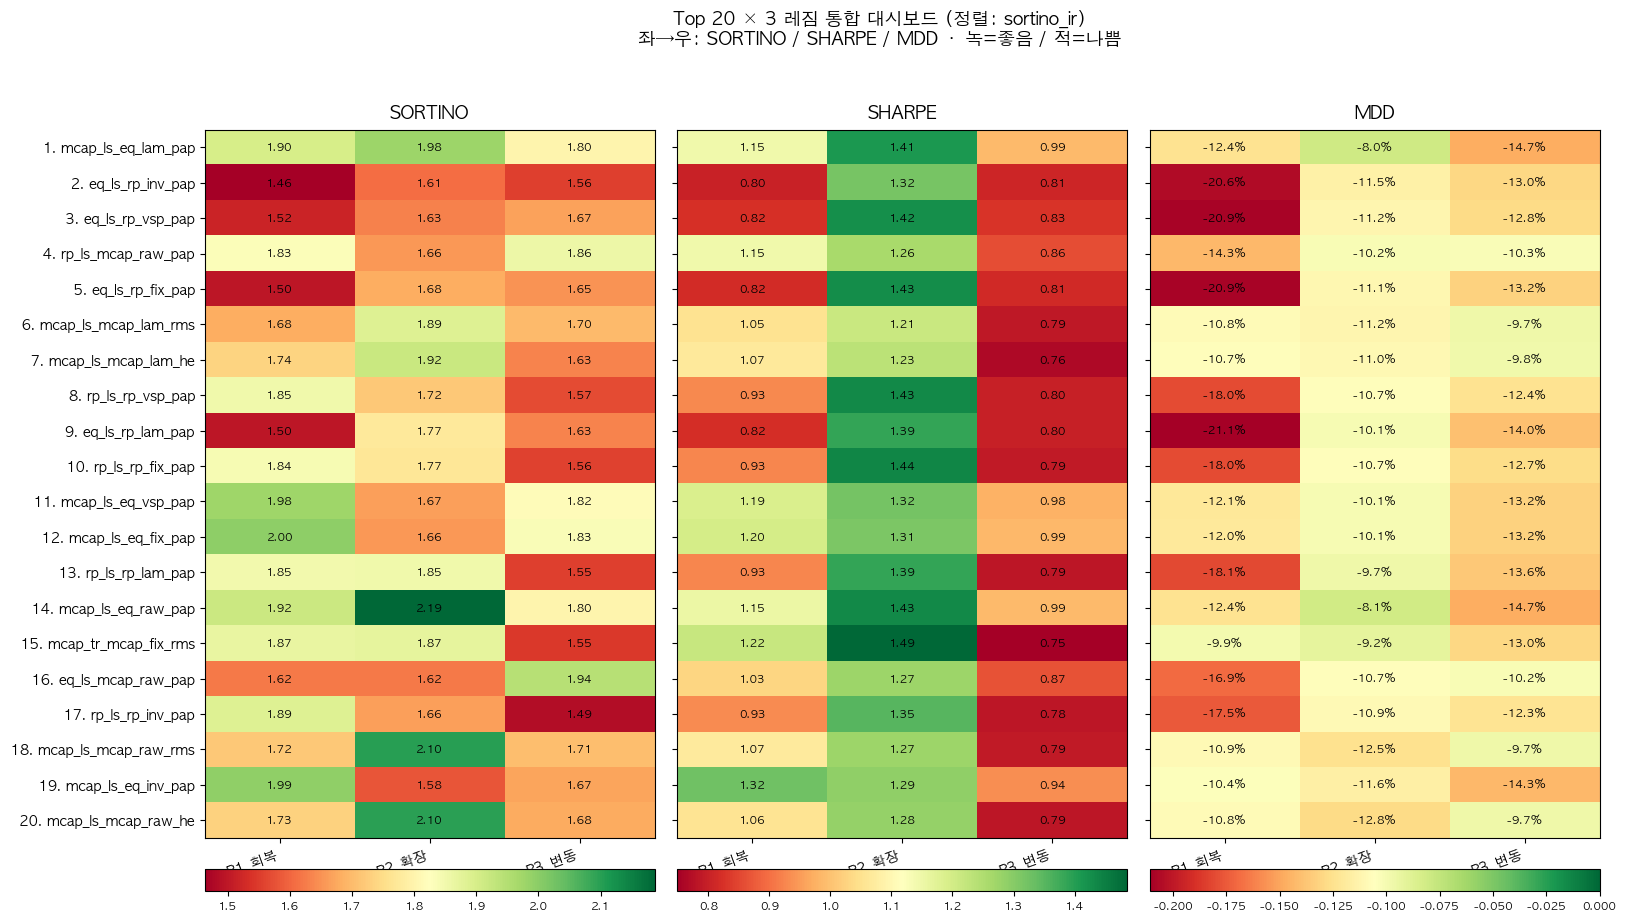

In [8]:
# ── K2. Sortino IR Top 20 통합 대시보드 + 비교군 우위 ─────
import importlib, master_table, analyze_plots
importlib.reload(master_table); importlib.reload(analyze_plots)
from analyze_plots import plot_styled_regime_dashboard

# rt가 K1에서 build됐다고 가정. composite_rank 제거되었으니 다시 빌드.
from master_table import build_regime_table, REGIMES
rt = build_regime_table(mt, RESULTS_DIR, rf, regimes=REGIMES)


# 비교군 5-레짐 sortino
print('■ 레짐별 Sortino — 핵심 비교군 4종')
print(f'{"레짐":<12} {"SPY":>7} {"baseline":>10} {"capm_no_bl":>12} {"naive_low":>11}')
print('-' * 56)
bench_sortinos = {'SPY': {}, 'baseline': {}, 'capm_no_bl': {}, 'naive_lowvol': {}}
for lbl, s, e in REGIMES:
    sm = regime_metrics(spy_ret,           rf, s, e)['sortino']
    bm = regime_metrics(baseline_ret,      rf, s, e)['sortino']
    cm = regime_metrics(capm_no_bl_ret,    rf, s, e)['sortino']
    nm = regime_metrics(naive_lowvol_ret,  rf, s, e)['sortino']
    bench_sortinos['SPY'][lbl]          = sm
    bench_sortinos['baseline'][lbl]     = bm
    bench_sortinos['capm_no_bl'][lbl]   = cm
    bench_sortinos['naive_lowvol'][lbl] = nm
    print(f'{lbl:<12} {sm:>7.2f} {bm:>10.2f} {cm:>12.2f} {nm:>11.2f}')

# ── K2-A. Sortino IR Top 20 — 3 metric × 5 레짐 통합 대시보드 (PNG) ─
print('\n\n=== K2-A. Sortino IR 정렬 Top 20 대시보드 ===')
print('  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨')

_ = plot_styled_regime_dashboard(
    rt, rank_by='sortino_ir', top_n=20,
    save_path=OUT_DIR / 'K2A_sortino_ir_dashboard.png',
)

# 행 매핑 표
top20 = rt.nlargest(20, 'sortino_ir').reset_index(drop=True); top20.index += 1
print('\n■ K2-A 행 매핑 (sortino_ir 큰 순)')
display(top20[['canonical','sortino_ir','sortino_mean','sortino_std','mdd_worst','sharpe']].round(3))

# ── K2-B. 비교군 우위 카운트 ──────────────────────────────────
print('\n\n=== K2-B. 핵심 비교군 대비 레짐 우위 카운트 ===')
print('1순위: SPY (액티브 펀드 출시 기준) / 2순위: naive_lowvol (USMV 카테고리)')

import numpy as np
rt_beat = rt.copy()
for bname in ['SPY','baseline','capm_no_bl','naive_lowvol']:
    bs = bench_sortinos[bname]
    counts = []
    for _, row in rt_beat.iterrows():
        n = sum(1 for lbl,_,_ in REGIMES
                if pd.notna(row[f'sortino_{lbl}']) and pd.notna(bs[lbl]) and row[f'sortino_{lbl}'] > bs[lbl])
        counts.append(n)
    rt_beat[f'n_beat_{bname}'] = counts

print('\n■ SPY 대비 우위 레짐 수 Top 10')
top_beat = rt_beat.sort_values(['n_beat_SPY','sortino_mean'], ascending=[False, False]).head(10).reset_index(drop=True)
top_beat.index += 1
display(top_beat[['canonical','n_beat_SPY','n_beat_naive_lowvol','n_beat_baseline','n_beat_capm_no_bl',
                  'sortino_mean','mdd_worst','sharpe']].round(3))

print('\n■ n_beat_SPY 분포 (전체)')
print(rt_beat['n_beat_SPY'].value_counts().sort_index().to_string())


## K2-T. Sortino IR Top 20 — 전체기간 메트릭 표

K2 대시보드 후보(sortino_ir 정렬 Top 20)를 **전체기간 단일 수치**로 정리. 발표·보고용.

메트릭: Sharpe / Sortino / CAGR / 변동성 / MDD / Beta / Alpha (모두 TC 차감 후)

In [9]:
# ── K2-T. Sortino IR Top 20 — 전체기간 메트릭 표 ───────────────────
# 표시 메트릭: Sharpe / Sortino / CAGR / 변동성(Vol) / MDD / Beta / Alpha

top20_names = rt.nlargest(20, 'sortino_ir')['name'].tolist()
summary = mt[mt['name'].isin(top20_names)].copy()
# rt 정렬 순서 유지
summary['_order'] = summary['name'].map({n: i for i, n in enumerate(top20_names)})
summary = summary.sort_values('_order').drop(columns='_order')

# 헤더
header = '=' * 92
sep    = '-' * 92
print(header)
print(f'{"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)

# 행 출력 (canonical 표시)
for _, r in summary.iterrows():
    name   = r['canonical'][:31]
    sh     = f'{r["sharpe"]:.3f}'
    so     = f'{r["sortino"]:.3f}'
    cagr   = f'{r["cagr"]*100:.2f}%'
    vol    = f'{r["vol"]*100:.2f}%'
    mdd    = f'{r["mdd"]*100:.2f}%'
    beta   = f'{r["beta"]:.3f}'  if pd.notna(r['beta'])  else '-'
    alpha  = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
    print(f'{name:<32}{sh:>8}{so:>9}{cagr:>8}{vol:>8}{mdd:>9}{beta:>8}{alpha:>8}')

print(header)

# 비교군도 함께 (참고)
print('\n■ 비교군 4종 — 전체기간')
print(sep)
print(f'{"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)
for nm in ['baseline','capm_no_bl','naive_lowvol']:
    r = mt[mt['name']==nm].iloc[0]
    name   = nm[:31]
    sh     = f'{r["sharpe"]:.3f}'
    so     = f'{r["sortino"]:.3f}'
    cagr   = f'{r["cagr"]*100:.2f}%'
    vol    = f'{r["vol"]*100:.2f}%'
    mdd    = f'{r["mdd"]*100:.2f}%'
    beta   = f'{r["beta"]:.3f}'  if pd.notna(r['beta'])  else '-'
    alpha  = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
    print(f'{name:<32}{sh:>8}{so:>9}{cagr:>8}{vol:>8}{mdd:>9}{beta:>8}{alpha:>8}')

# SPY 별도 계산
from bl_functions import compute_metrics
spy_m = compute_metrics(spy_ret, rf, label='SPY', mkt_ret=spy_ret)
print(f'{"SPY":<32}{spy_m["sharpe"]:>8.3f}{spy_m["sortino"]:>9.3f}{spy_m["cagr"]*100:>7.2f}%{spy_m["vol"]*100:>7.2f}%{spy_m["mdd"]*100:>8.2f}%{"-":>8}{"-":>8}')
print(header)

실험명                               Sharpe  Sortino    CAGR     변동성      MDD    Beta   Alpha
--------------------------------------------------------------------------------------------
mcap_ls_eq_lam_pap                 1.140    1.796  16.23%  12.79%  -14.68%   0.725   5.02%
eq_ls_rp_inv_pap                   0.977    1.506  15.45%  14.45%  -20.55%   0.916   1.92%
eq_ls_rp_vsp_pap                   1.016    1.565  15.85%  14.19%  -20.85%   0.882   2.67%
rp_ls_mcap_raw_pap                 1.038    1.687  14.75%  12.77%  -14.33%   0.713   3.75%
eq_ls_rp_fix_pap                   1.013    1.571  15.89%  14.30%  -20.86%   0.874   2.83%
mcap_ls_mcap_lam_rms               1.017    1.757  12.60%  10.95%  -11.16%   0.522   4.19%
mcap_ls_mcap_lam_he                1.022    1.791  12.69%  11.17%  -10.96%   0.540   4.13%
rp_ls_rp_vsp_pap                   1.032    1.596  15.17%  13.27%  -18.01%   0.815   2.86%
eq_ls_rp_lam_pap                   0.996    1.586  15.54%  14.22%  -21.08%   0.808   3.3

## K2-H. Sharpe IR 정렬 Top 20 × 3 metric 히트맵

`sortino_ir`(mean/std) 기준 정렬과 별개로 **`sharpe_ir = sharpe_mean / sharpe_std`** 기준으로 Top 20 추출.
3 metric (sortino, sharpe, mdd) per 레짐 히트맵으로 시각화.

→ Sortino 안정성 측면(K2-B)과 Sharpe 안정성 측면(여기) 둘 다 비교 가능.


=== K2-H. Sharpe IR 정렬 Top 20 대시보드 ===
  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨



■ K2-H 행 매핑 (sharpe_ir 큰 순)


,canonical,sharpe_ir,sharpe_mean,sortino_ir,mdd_worst
1,mcap_ls_mcap_fix_pap,20.65,0.991,4.05,-0.162
2,mcap_ls_mcap_vsp_pap,12.92,0.995,3.63,-0.163
3,mcap_ls_mcap_inv_pap,11.33,1.065,5.42,-0.157
4,mcap_ls_mcap_lam_pap,10.83,0.975,4.48,-0.162
5,eq_ls_mcap_lam_pap,9.16,0.998,8.75,-0.169
6,mcap_ls_eq_fix_pap,8.64,1.166,13.16,-0.132
7,mcap_ls_eq_vsp_pap,8.25,1.163,14.33,-0.132
8,rp_ls_mcap_lam_pap,8.17,1.029,9.21,-0.143
9,eq_ls_mcap_fix_pap,7.35,0.992,7.60,-0.163
10,eq_ls_mcap_vsp_pap,6.94,1.000,7.12,-0.167



■ Sortino IR Top 20 ∩ Sharpe IR Top 20 = 두 측면 모두 강한 후보
  교집합: 8개


,canonical,sortino_ir,sharpe_ir,sortino_mean,mdd_worst,sharpe
54,mcap_ls_eq_lam_pap,26.31,6.79,1.894,-0.147,1.140
117,rp_ls_mcap_raw_pap,20.03,6.48,1.783,-0.143,1.038
70,mcap_ls_mcap_lam_rms,18.88,5.82,1.756,-0.112,1.017
60,mcap_ls_eq_vsp_pap,14.33,8.25,1.820,-0.132,1.120
48,mcap_ls_eq_fix_pap,13.16,8.64,1.829,-0.132,1.121
57,mcap_ls_eq_raw_pap,12.15,6.47,1.968,-0.147,1.144
27,eq_ls_mcap_raw_pap,11.46,6.29,1.730,-0.169,1.024
51,mcap_ls_eq_inv_pap,9.93,6.76,1.748,-0.143,1.119


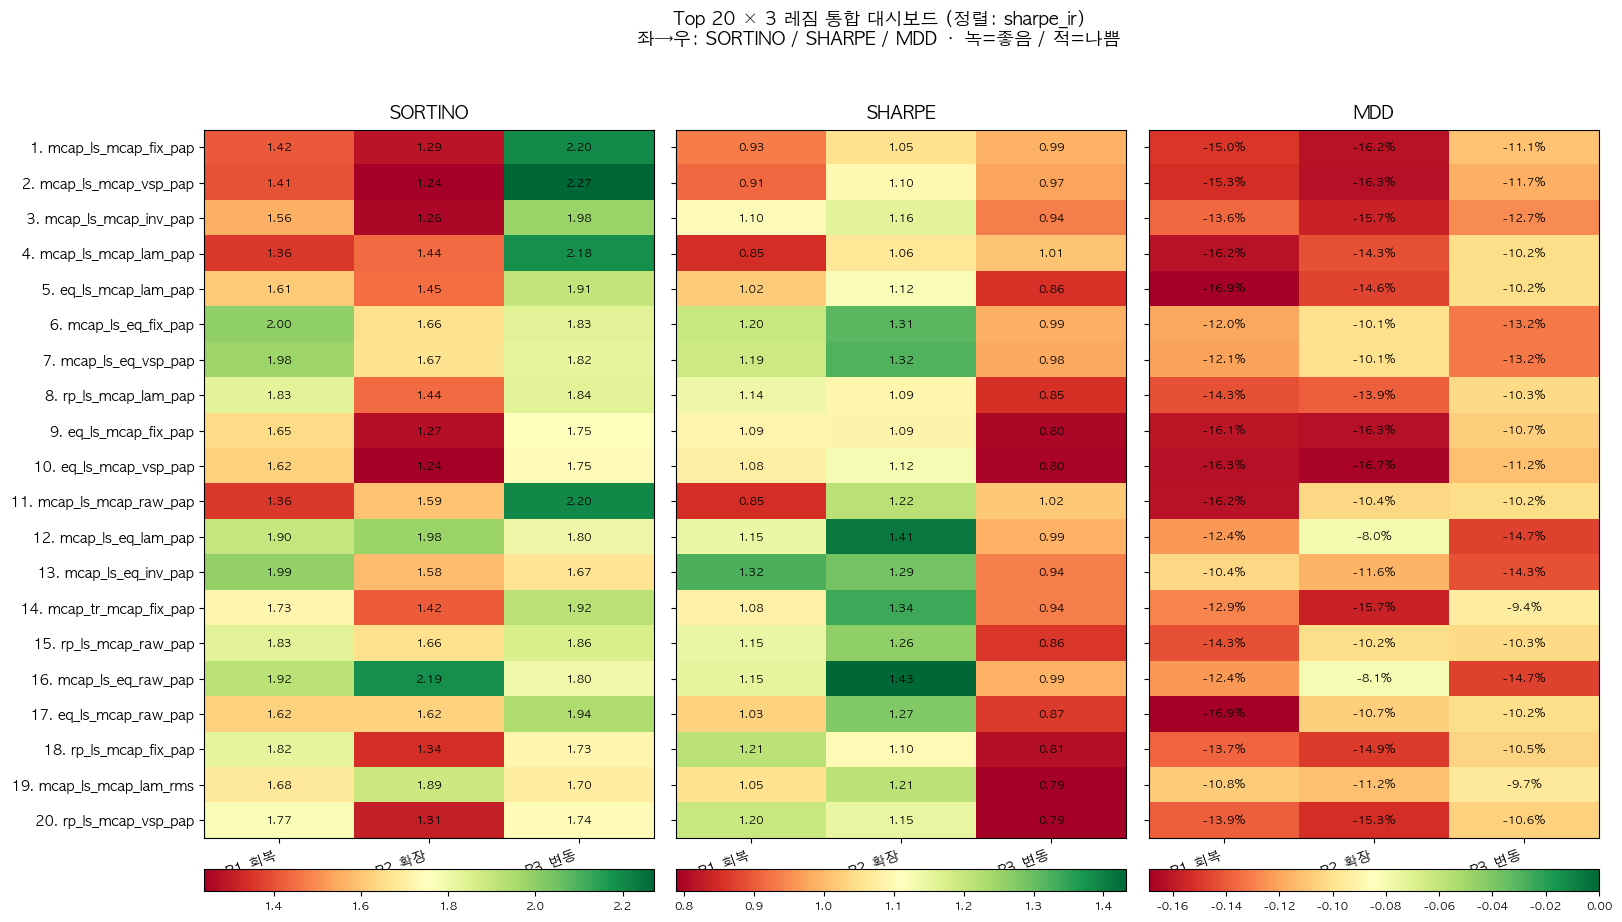

In [10]:
# ── K2-H. Sharpe IR Top 20 통합 대시보드 + 두 IR 교집합 ─────
import importlib, master_table, analyze_plots
importlib.reload(master_table); importlib.reload(analyze_plots)
from analyze_plots import plot_styled_regime_dashboard

    

print('=== K2-H. Sharpe IR 정렬 Top 20 대시보드 ===')
print('  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨')

_ = plot_styled_regime_dashboard(
    rt, rank_by='sharpe_ir', top_n=20,
    save_path=OUT_DIR / 'K2H_sharpe_ir_dashboard.png',
)

top20_sh = rt.nlargest(20, 'sharpe_ir').reset_index(drop=True); top20_sh.index += 1
print('\n■ K2-H 행 매핑 (sharpe_ir 큰 순)')
display(top20_sh[['canonical','sharpe_ir','sharpe_mean','sortino_ir','mdd_worst']].round(3))

# Sortino IR ∩ Sharpe IR Top 20 교집합
print('\n■ Sortino IR Top 20 ∩ Sharpe IR Top 20 = 두 측면 모두 강한 후보')
set_so = set(rt.nlargest(20, 'sortino_ir')['canonical'])
set_sh = set(top20_sh['canonical'])
inter = set_so & set_sh
print(f'  교집합: {len(inter)}개')
if inter:
    display(rt[rt['canonical'].isin(inter)].sort_values('sortino_ir', ascending=False)
              [['canonical','sortino_ir','sharpe_ir','sortino_mean','mdd_worst','sharpe']]
              .round(3))


## K7. baseline Q 민감도 — q_value ∈ {0.003, 0.0055, 0.0064, 0.0070}

**baseline** (q_mode='fixed', 모든 다른 슬롯 default)에서 q_value만 변경한 4종 비교.

**학술 근거** (Frazzini-Pedersen 2014, BAB 월평균):
- 0.003: 현 baseline (BAB의 약 절반, 보수적 view 강도)
- 0.0055: 4팩터 알파 보수치
- 0.0064: 글로벌 19개국 평균
- 0.0070: 미국 평균

**검증 목적**: BAB 학술 평균으로 Q를 올리면 성과가 일관 개선되는가, 단조 감소하는가?

### 분석 구성
1. **K7-A 전체기간 메트릭 표** — Sharpe/Sortino/CAGR/MDD/Beta/Alpha/IR
2. **K7-B 레짐별 Sortino/Sharpe/MDD** — 3-레짐(R1 회복 / R2 확장 / R3 변동)별 비교로 시기별 robust 여부 점검


=== K7-A. 전체기간 메트릭 ===
   q_value    Sharpe  Sortino    CAGR     변동성      MDD    Beta   Alpha  sortino_ir  sharpe_ir
----------------------------------------------------------------------------------------------------
    0.0030     1.106    1.726  13.55%  10.98%  -13.03%   0.626   3.87%       9.830      3.790
    0.0055     1.037    1.741  12.44%  10.52%  -13.70%   0.524   3.95%       8.550      3.760
    0.0064     1.021    1.719  12.22%  10.50%  -14.71%   0.502   4.05%       7.730      3.600
    0.0070     1.014    1.698  12.12%  10.48%  -14.82%   0.486   4.15%       6.710      3.510

■ 단조성 패턴 (q_value 0.003 → 0.0070)
  sharpe      : ↓↓↓ 단조 감소 (q=0.003 최적)
  sortino     : q=0.0055 최고 (1.741)
  cagr        : ↓↓↓ 단조 감소 (q=0.003 최적)
  sortino_ir  : ↓↓↓ 단조 감소 (q=0.003 최적)
  sharpe_ir   : ↓↓↓ 단조 감소 (q=0.003 최적)

해석: 단조 감소 패턴이면 q=0.003이 우리 setup에 calibrate된 최적값.
       BAB 학술 평균(0.0064~0.0070)으로 올려도 성과 개선 없음 → 0.003 유지가 robust.


=== K7-B. 레짐별 Sortino / Sharpe / MDD ===
  (전체기간 단조 패턴이 모든 

,R1_회복,R2_확장,R3_변동
q_value,,,
0.0030,1.952,1.831,1.525
0.0055,1.952,1.954,1.505
0.0064,1.954,1.976,1.471
0.0070,1.949,1.995,1.409


  → 레짐별 단조성 (Sortino):
    R1_회복     : q=0.0064 최고
    R2_확장     : ↑↑↑ 단조 증가
    R3_변동     : ↓↓↓ 단조 감소

[ Sharpe per 레짐 ]


,R1_회복,R2_확장,R3_변동
q_value,,,
0.0030,1.245,1.456,0.736
0.0055,1.356,1.327,0.705
0.0064,1.390,1.302,0.687
0.0070,1.411,1.291,0.679


  → 레짐별 단조성 (Sharpe):
    R1_회복     : ↑↑↑ 단조 증가
    R2_확장     : ↓↓↓ 단조 감소
    R3_변동     : ↓↓↓ 단조 감소

[ MDD per 레짐 ]


,R1_회복,R2_확장,R3_변동
q_value,,,
0.003000,-9.69%,-9.27%,-13.03%
0.005500,-8.73%,-8.51%,-13.70%
0.006400,-8.38%,-8.62%,-14.71%
0.007000,-8.10%,-9.02%,-14.82%


  → 레짐별 단조성 (MDD):
    R1_회복     : ↑↑↑ 단조 증가
    R2_확장     : q=0.0055 최고
    R3_변동     : ↓↓↓ 단조 감소


=== K7-C. 레짐 × 메트릭 시각화 ===


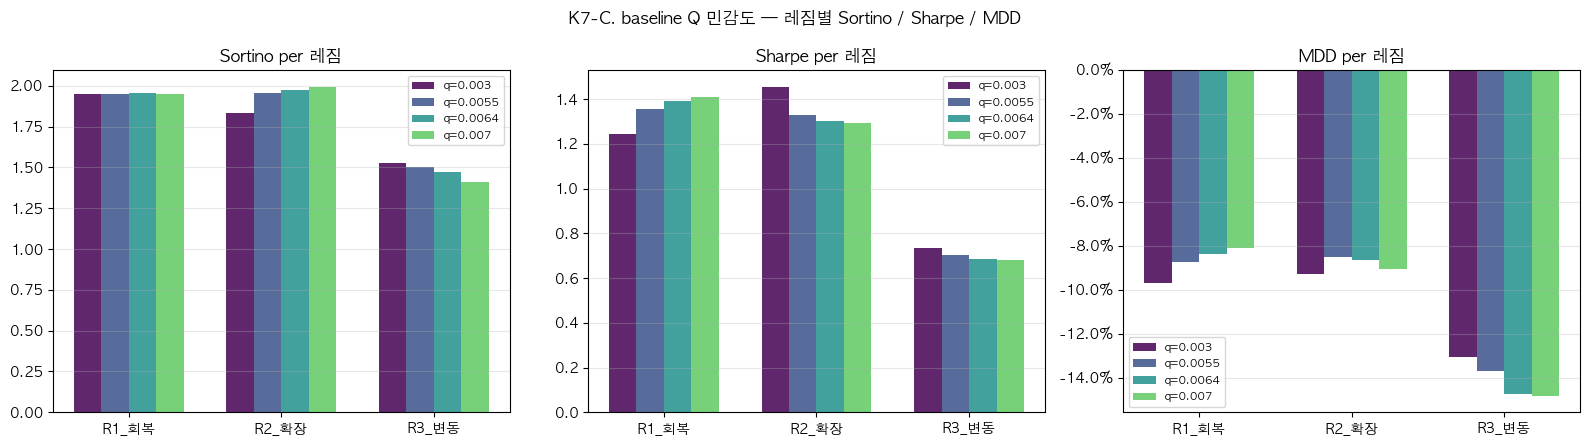


해석: 모든 레짐에서 q=0.003이 일관되게 우위면 → 시기 무관 robust 결론.
       특정 레짐에서만 다른 q가 우위면 → 단순 캘리브레이션 효과 (전체기간 평균에 묻힌 차이).


In [11]:
# ── K7. baseline Q 민감도 — q_value ∈ {0.003, 0.0055, 0.0064, 0.0070} ──
# A) 전체기간 메트릭 + 단조성 진단
# B) 레짐별 Sortino / Sharpe / MDD

import pickle
from master_table import regime_metrics, REGIMES

Q_NAMES = [('baseline', 0.003), ('baseline_q55', 0.0055),
           ('baseline_q64', 0.0064), ('baseline_q70', 0.0070)]

# ── K7-A. 전체기간 메트릭 표 ──────────────────────────────────────
header = '=' * 100
sep    = '-' * 100
print('=== K7-A. 전체기간 메트릭 ===')
print(header)
print(f'{"q_value":>10}  {"Sharpe":>8}{"Sortino":>9}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}{"sortino_ir":>12}{"sharpe_ir":>11}')
print(sep)

for nm, q in Q_NAMES:
    m = mt_full[mt_full['name']==nm]
    r = rt_full[rt_full['name']==nm]
    if len(m)==0:
        print(f'{q:>10.4f}  [pkl 없음 — {nm}]')
        continue
    m, r = m.iloc[0], r.iloc[0]
    print(f'{q:>10.4f}  {m["sharpe"]:>8.3f}{m["sortino"]:>9.3f}{m["cagr"]*100:>7.2f}%{m["vol"]*100:>7.2f}%{m["mdd"]*100:>8.2f}%{m["beta"]:>8.3f}{m["alpha"]*100:>7.2f}%{r["sortino_ir"]:>12.3f}{r["sharpe_ir"]:>11.3f}')
print(header)

# 단조성 패턴 자동 진단
print('\n■ 단조성 패턴 (q_value 0.003 → 0.0070)')
for metric in ['sharpe','sortino','cagr','sortino_ir','sharpe_ir']:
    if metric in ['sortino_ir','sharpe_ir']:
        vals = [rt_full[rt_full['name']==nm].iloc[0][metric] for nm,_ in Q_NAMES if len(rt_full[rt_full['name']==nm])>0]
    else:
        vals = [mt_full[mt_full['name']==nm].iloc[0][metric] for nm,_ in Q_NAMES if len(mt_full[mt_full['name']==nm])>0]
    if len(vals) < 4:
        print(f'  {metric:<12}: 데이터 부족'); continue
    if vals[0] > vals[1] > vals[2] > vals[3]:
        pat = '↓↓↓ 단조 감소 (q=0.003 최적)'
    elif vals[0] < vals[1] < vals[2] < vals[3]:
        pat = '↑↑↑ 단조 증가 (q=0.0070 최적)'
    else:
        max_idx = int(np.argmax(vals))
        max_q = Q_NAMES[max_idx][1]
        pat = f'q={max_q} 최고 ({vals[max_idx]:.3f})'
    print(f'  {metric:<12}: {pat}')

print('\n해석: 단조 감소 패턴이면 q=0.003이 우리 setup에 calibrate된 최적값.')
print('       BAB 학술 평균(0.0064~0.0070)으로 올려도 성과 개선 없음 → 0.003 유지가 robust.')

# ── K7-B. 레짐별 Sortino / Sharpe / MDD ──────────────────────────
print('\n\n=== K7-B. 레짐별 Sortino / Sharpe / MDD ===')
print('  (전체기간 단조 패턴이 모든 레짐에서 일관되는지 점검)')

# q별 ret 로드
q_rets = {}
for nm, q in Q_NAMES:
    pkl = RESULTS_DIR / f'{nm}.pkl'
    if not pkl.exists():
        continue
    with open(pkl, 'rb') as f:
        q_rets[(nm, q)] = pickle.load(f)['ret'].dropna()

# 메트릭별 표
for metric_key, metric_label, fmt_pct in [
    ('sortino', 'Sortino', False),
    ('sharpe',  'Sharpe',  False),
    ('mdd',     'MDD',     True),
]:
    print(f'\n[ {metric_label} per 레짐 ]')
    rows = []
    for (nm, q), ret in q_rets.items():
        rec = {'q_value': q}
        for lbl, s, e in REGIMES:
            v = regime_metrics(ret, rf, s, e)[metric_key]
            rec[lbl] = v if not pd.isna(v) else np.nan
        rows.append(rec)
    df_m = pd.DataFrame(rows).set_index('q_value')
    if fmt_pct:
        display(df_m.style.format('{:.2%}'))
    else:
        display(df_m.round(3))

    # 레짐별 단조성 진단
    print(f'  → 레짐별 단조성 ({metric_label}):')
    for lbl, _, _ in REGIMES:
        vals = [r[lbl] for r in rows if not pd.isna(r[lbl])]
        if len(vals) < 4:
            print(f'    {lbl:<10}: 데이터 부족'); continue
        # MDD: 더 얕은 게 좋음 (값이 큼, -0.10 > -0.20)
        # Sortino/Sharpe: 큰 게 좋음
        if metric_key == 'mdd':
            best_idx = int(np.argmax(vals))  # 가장 얕은 MDD = 가장 큰 값
        else:
            best_idx = int(np.argmax(vals))
        best_q = Q_NAMES[best_idx][1]
        if vals[0] > vals[1] > vals[2] > vals[3]:
            pat = '↓↓↓ 단조 감소'
        elif vals[0] < vals[1] < vals[2] < vals[3]:
            pat = '↑↑↑ 단조 증가'
        else:
            pat = f'q={best_q} 최고'
        print(f'    {lbl:<10}: {pat}')

# ── K7-C. 시각화: 레짐 × 메트릭 그리드 ──────────────────────────
print('\n\n=== K7-C. 레짐 × 메트릭 시각화 ===')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metric_specs = [('sortino', 'Sortino', '#2E75B6'),
                ('sharpe',  'Sharpe',  '#ED7D31'),
                ('mdd',     'MDD',     '#A5A5A5')]

q_values = [q for _, q in Q_NAMES if (Q_NAMES[[i for i,(_,qq) in enumerate(Q_NAMES) if qq==q][0]][0], q) in q_rets]
regime_labels = [lbl for lbl,_,_ in REGIMES]

for ax, (mk, ml, color) in zip(axes, metric_specs):
    # x=레짐, group=q_value
    width = 0.18
    x = np.arange(len(regime_labels))
    cmap = plt.cm.get_cmap('viridis', len(q_values)+1)
    for i, q in enumerate(q_values):
        nm = [nm for nm, qq in Q_NAMES if qq == q][0]
        if (nm, q) not in q_rets:
            continue
        ret = q_rets[(nm, q)]
        vals = [regime_metrics(ret, rf, s, e)[mk] for _, s, e in REGIMES]
        ax.bar(x + (i - 1.5) * width, vals, width, label=f'q={q}', color=cmap(i), alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(regime_labels)
    ax.set_title(f'{ml} per 레짐', fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    if mk == 'mdd':
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=8, loc='best')
    ax.axhline(0, color='black', lw=0.5)

fig.suptitle('K7-C. baseline Q 민감도 — 레짐별 Sortino / Sharpe / MDD', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(OUT_DIR / 'K7_q_sensitivity_regime.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n해석: 모든 레짐에서 q=0.003이 일관되게 우위면 → 시기 무관 robust 결론.')
print('       특정 레짐에서만 다른 q가 우위면 → 단순 캘리브레이션 효과 (전체기간 평균에 묻힌 차이).')
